# Momentum & Value Strategy Backtester — Phase 1

**Strategy:** long-only, equal-weight, monthly-rebalanced 12-1 month momentum on the S&P 500.

**Why 12-1 momentum?** This is the classic academic specification (Jegadeesh & Titman-style):
rank stocks by their return from 12 months ago to 1 month ago, explicitly *skipping* the most
recent month. The skip matters because stock returns show short-term (1-month) *reversal* —
last month's winners tend to partially give it back over the next month — which is the opposite
effect from momentum and would contaminate the signal if included.

**Why point-in-time S&P 500 membership?** Using today's S&P 500 list for the whole 15-year
backtest would be *survivorship bias*: any company that was in the index and later got removed
(bankruptcy, acquisition, demotion) would be invisible to the strategy, silently inflating
returns. This notebook tracks index membership **as it actually was** on each historical date.

**Why net of transaction costs?** A backtest that ignores trading costs overstates real returns,
especially here where a meaningful chunk of the portfolio turns over every month. Every result
below is shown gross *and* net of a realistic, literature-referenced cost assumption, so it's
clear exactly how much costs erode returns rather than hiding a single already-net number.

**No parameters here were tuned to this dataset.** The headline spec (12-1 lookback, top 50,
monthly rebalance) matches the standard academic definition. A robustness appendix at the end
reruns nearby parameter choices to show the result isn't a fragile, cherry-picked one-off.


## 1. Setup

In [1]:
import sys
from pathlib import Path
from dataclasses import replace

import pandas as pd

# Allow `import src.*` when this notebook is run from the notebooks/ directory.
sys.path.append(str(Path("..").resolve()))

from src.config import DEFAULT_CONFIG
from src.data_layer.constituents import load_constituents_table, get_membership
from src.data_layer.prices import get_prices
from src.data_layer.quality_checks import find_price_outliers
from src.strategy.momentum import compute_momentum_signal, select_top_n
from src.backtest.engine import run_backtest, compute_benchmark_result, compute_warmup_start
from src.evaluation.metrics import summary_table, cagr, sharpe_ratio, max_drawdown
from src.evaluation.plots import plot_equity_curves, plot_drawdown, plot_universe_size

config = DEFAULT_CONFIG
print(config)


BacktestConfig(start_date='2012-01-01', end_date='2026-06-30', lookback_months=12, skip_months=1, rebalance_freq='ME', top_n=50, benchmark_ticker='SPY', risk_free_rate=0.0, one_way_cost_bps=10.0, price_outlier_threshold=0.5, cache_dir=WindowsPath('C:/Users/arwga/Developer/ClaudeProjects/MomentumValueStrategy/data/cache'), constituents_url='https://raw.githubusercontent.com/fja05680/sp500/master/S%26P%20500%20Historical%20Components%20%26%20Changes%20(Updated).csv')


## 2. Point-in-time universe

Before touching any prices, let's see the point-in-time S&P 500 membership data itself, and
confirm it actually changes over time (a basic sanity check that we're not accidentally using a
static, present-day list).

In [2]:
constituents_table = load_constituents_table(cache_dir=config.cache_dir, url=config.constituents_url)
print(f"Constituents table covers {constituents_table.index.min().date()} to {constituents_table.index.max().date()}")

sample_dates = ["2012-01-01", "2019-01-01", "2026-01-01"]
membership_by_date = {d: set(get_membership(d, constituents_table)) for d in sample_dates}
for d, members in membership_by_date.items():
    print(f"{d}: {len(members)} constituents")

# Concrete turnover between the earliest and latest sample dates.
added = membership_by_date["2026-01-01"] - membership_by_date["2012-01-01"]
removed = membership_by_date["2012-01-01"] - membership_by_date["2026-01-01"]
print(f"\nOf the 2012 constituents, {len(removed)} are no longer in the index by 2026.")
print(f"{len(added)} names present in 2026 were not present in 2012.")
print("Sample removed:", sorted(removed)[:10])


Constituents table covers 1996-01-02 to 2026-06-02
2012-01-01: 497 constituents
2019-01-01: 505 constituents
2026-01-01: 503 constituents

Of the 2012 constituents, 203 are no longer in the index by 2026.
209 names present in 2026 were not present in 2012.
Sample removed: ['AABA', 'ABC', 'AET', 'AGN', 'AIV', 'ALTR', 'AN', 'ANDV', 'ANF', 'ANRZQ']


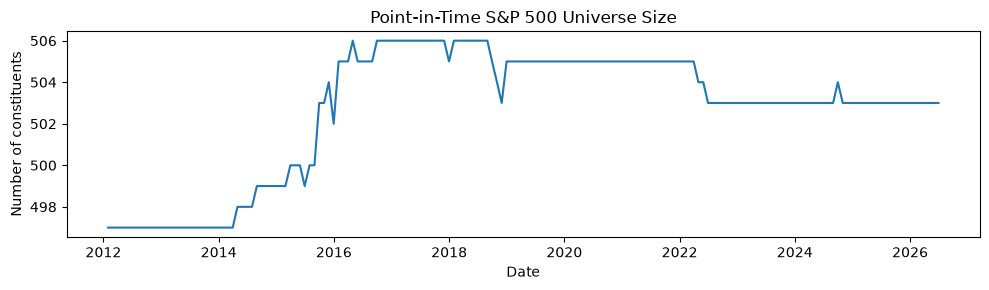

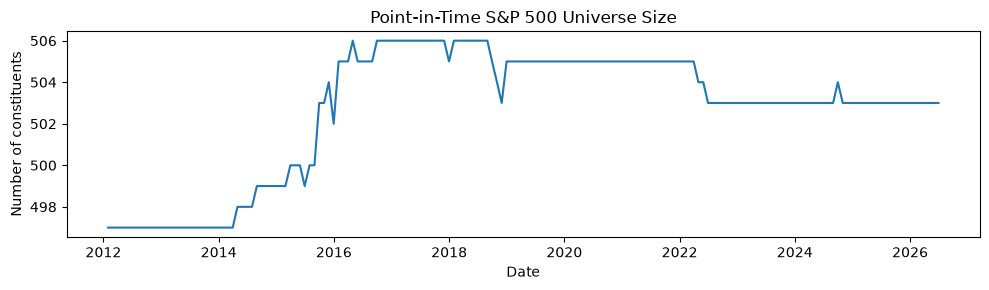

In [3]:
requested_rebalance_dates = pd.date_range(config.start_date, config.end_date, freq=config.rebalance_freq)
universe_size_by_date = pd.Series(
    {d: len(get_membership(d, constituents_table)) for d in requested_rebalance_dates}
)
plot_universe_size(universe_size_by_date)


## 3. Price data

Fetch adjusted close prices for every ticker that was ever an S&P 500 constituent during the
backtest window, plus the SPY benchmark. Prices are cached locally (`data/cache/prices/`) so
repeat runs don't re-hit yfinance. Some tickers will fail to download (delisted, renamed,
bankrupt, or simply not on Yahoo Finance) — this is expected and reported transparently rather
than silently ignored.

In [4]:
all_tickers = set()
for d in requested_rebalance_dates:
    all_tickers.update(get_membership(d, constituents_table))
all_tickers.add(config.benchmark_ticker)

# Computing 12-1 momentum at the first rebalance date needs 13 months of prior
# price history, so we fetch from (start_date - lookback_months - skip_months)
# onward rather than from start_date itself. This is the same "warmup window"
# offset run_backtest() applies internally - reused here so the notebook and
# the engine can never drift out of sync on this calculation.
warmup_start = compute_warmup_start(config.start_date, config.lookback_months, config.skip_months)
print(f"Fetching prices from {warmup_start} (warmup) through {config.end_date} for {len(all_tickers)} tickers...")

daily_prices, failed_tickers = get_prices(sorted(all_tickers), warmup_start, config.end_date, cache_dir=config.cache_dir)

print(f"\nSucceeded: {daily_prices.shape[1]} tickers")
print(f"Failed:    {len(failed_tickers)} tickers (delisted/renamed/no data)")
print("Sample failed tickers:", failed_tickers[:15])


Fetching prices from 2010-12-01 (warmup) through 2026-06-30 for 807 tickers...


$CFN: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)
$GMCR: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)
$ENDP: possibly delisted; no timezone found
$CTXS: possibly delisted; no timezone found
$DISCA: possibly delisted; no timezone found
$ALTR: possibly delisted; no timezone found
$FTR: possibly delisted; no timezone found
$FI: possibly delisted; no timezone found
$FLT: possibly delisted; no timezone found
$DISCK: possibly delisted; no timezone found
$BTUUQ: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)
$AGN: possibly delisted; no timezone found
$HES: possibly delisted; no timezone found
$BIG: possibly delisted; no timezone found
$ETFC: possibly delisted; no timezone found
$DFS: possibly delisted; no timezone found
$CDAY: possibly delisted; no timezone found
$DISH: possibly delisted; no timezone found
$ARNC: possibly delisted; no timezone found
$ANRZQ: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-


Succeeded: 648 tickers
Failed:    159 tickers (delisted/renamed/no data)
Sample failed tickers: ['AABA', 'ABC', 'ABMD', 'ADS', 'AGN', 'ALTR', 'ALXN', 'ANRZQ', 'ANSS', 'ANTM', 'APOL', 'ARG', 'ARNC', 'ATGE', 'ATVI']


In [5]:
# Data quality check: flag suspicious single-day price moves rather than trusting them blindly.
outliers = find_price_outliers(daily_prices, threshold=config.price_outlier_threshold)
print(f"Flagged {len(outliers)} single-day moves beyond {config.price_outlier_threshold:.0%}:")
outliers.head(15)


Flagged 651 single-day moves beyond 50%:


,date,ticker,daily_return
0,2016-02-09,CBE,33999.00076
1,2016-02-02,CBE,33999.00076
2,2016-01-26,CBE,33999.00076
3,2016-02-11,CBE,33999.00076
4,2016-02-23,CBE,33999.00076
5,2016-02-17,CBE,33999.00076
6,2016-01-22,CBE,33999.00076
7,2015-12-22,CBE,33999.00076
8,2015-12-17,CBE,33999.00076
9,2015-12-15,CBE,33999.00076


## 4. Momentum signal, illustrated

Before running the full backtest, let's compute the 12-1 momentum score for one rebalance date
by hand, to make the formula completely concrete.

In [6]:
month_end_prices = daily_prices.resample(config.rebalance_freq).last()
example_date = month_end_prices.index[month_end_prices.index >= pd.Timestamp(config.start_date)][0]

scores = compute_momentum_signal(month_end_prices, example_date, config.lookback_months, config.skip_months)
print(f"Momentum scores as of {example_date.date()} ({len(scores)} tickers with valid history):\n")
print("Top 10 (highest momentum):")
print(scores.sort_values(ascending=False).head(10))
print("\nBottom 10 (lowest momentum):")
print(scores.sort_values(ascending=True).head(10))


Momentum scores as of 2012-01-31 (527 tickers with valid history):

Top 10 (highest momentum):
TIE     370.352778
DPZ       1.070121
GNRC      0.881208
CTRA      0.825726
ULTA      0.752700
BIIB      0.680923
REGN      0.645784
DLTR      0.643140
MNST      0.626765
MA        0.578759
dtype: float64

Bottom 10 (lowest momentum):
FSLR   -0.781602
NFLX   -0.676336
GR     -0.642857
BAC    -0.593110
EP     -0.571429
ILMN   -0.560427
DXC    -0.544571
GNW    -0.517318
NKTR   -0.500446
RIG    -0.497843
dtype: float64


## 5. Full backtest run

In [7]:
result = run_backtest(config)

print(f"Rebalances: {len(result.gross_returns)}")
print(f"Average holdings per month: {sum(len(h) for h in result.holdings_history.values()) / len(result.holdings_history):.1f} (target: {config.top_n})")
print(f"Average monthly turnover: {result.turnover_history.mean():.1%}")
print(f"Missing forward-price occurrences (delistings mid-holding / data gaps): {result.missing_forward_price_count}")
print(f"Extreme-return exclusions (implausible >300% monthly gain, treated as a vendor data glitch): {result.extreme_return_count}")

$GMCR: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)
$CFN: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)
$FI: possibly delisted; no timezone found
$FLT: possibly delisted; no timezone found
$GPS: possibly delisted; no timezone found
$ENDP: possibly delisted; no timezone found
$DISCA: possibly delisted; no timezone found
$ALTR: possibly delisted; no timezone found
$ABC: possibly delisted; no timezone found
$CTXS: possibly delisted; no timezone found
$FTR: possibly delisted; no timezone found
$AGN: possibly delisted; no timezone found
$DISCK: possibly delisted; no timezone found
$BTUUQ: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)
$ANRZQ: possibly delisted; no price data found  (1d 2010-12-01 -> 2026-06-30)
$ARNC: possibly delisted; no timezone found
$DAY: possibly delisted; no timezone found
$ANTM: possibly delisted; no timezone found
$CDAY: possibly delisted; no timezone found
$BIG: possibly delisted; no timezone 

Rebalances: 173
Average holdings per month: 50.0 (target: 50)
Average monthly turnover: 28.8%
Missing forward-price occurrences (delistings mid-holding / data gaps): 0
Extreme-return exclusions (implausible >300% monthly gain, treated as a vendor data glitch): 0


## 6. Benchmark: SPY buy-and-hold

In [8]:
benchmark_returns, benchmark_equity = compute_benchmark_result(config)
print(f"SPY equity, start: {benchmark_equity.iloc[0]:.3f}, end: {benchmark_equity.iloc[-1]:.3f}")


SPY equity, start: 1.043, end: 7.263


## 7. Evaluation: Strategy (Gross) vs. Strategy (Net of costs) vs. Benchmark

In [9]:
table = summary_table(
    result.gross_returns, result.gross_equity,
    result.net_returns, result.net_equity,
    benchmark_returns, benchmark_equity,
    risk_free_rate=config.risk_free_rate,
)
table


,Strategy (Gross),Strategy (Net of costs),Benchmark
CAGR,0.164458,0.156648,0.144967
Annualized Volatility,0.169464,0.169445,0.140599
Sharpe Ratio,0.999587,0.958946,1.053799
Max Drawdown,-0.196131,-0.197207,-0.239272


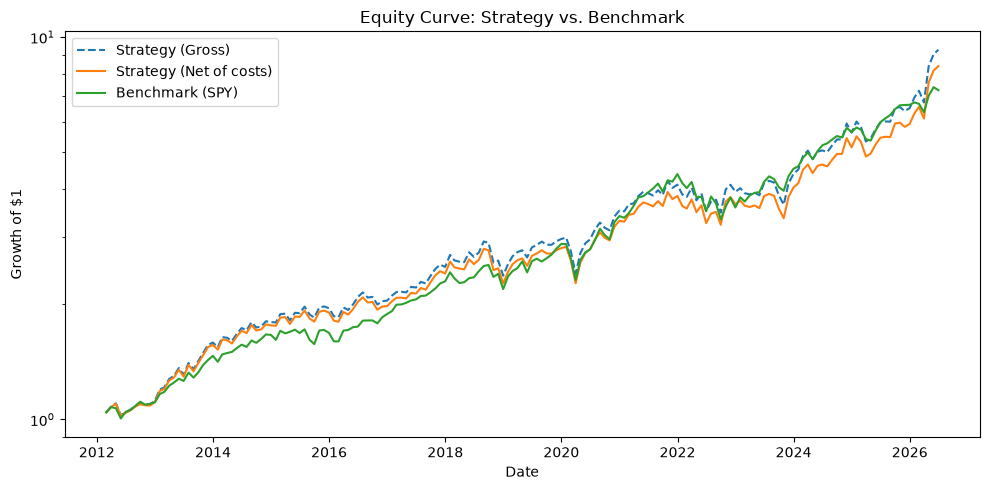

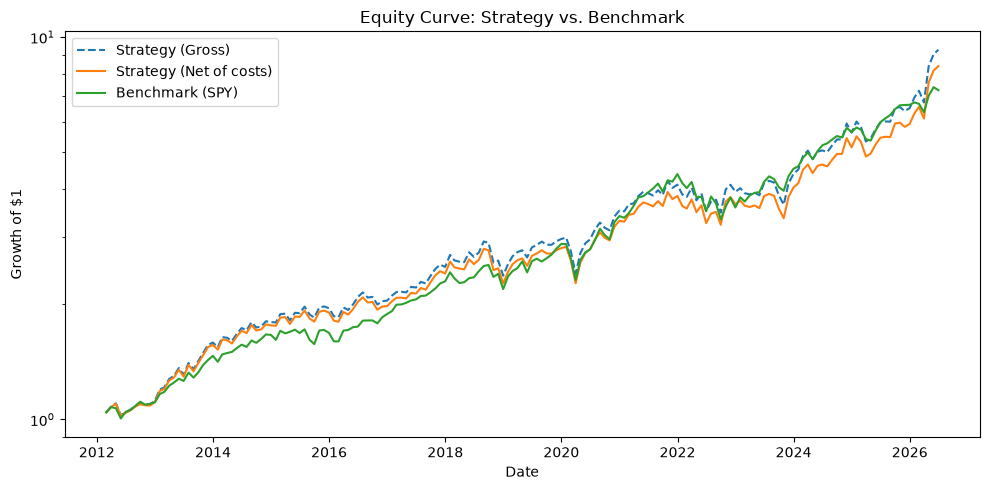

In [10]:
plot_equity_curves(result.gross_equity, result.net_equity, benchmark_equity, log_scale=True)


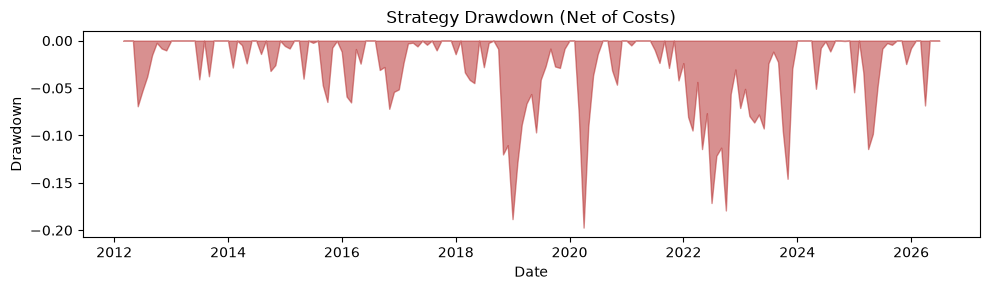

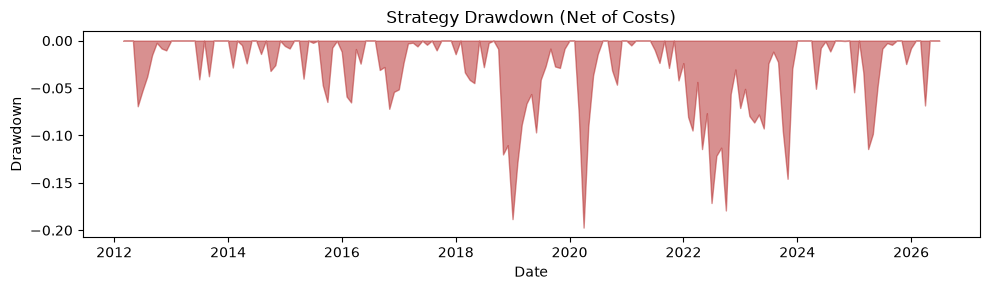

In [11]:
plot_drawdown(result.net_equity, title="Strategy Drawdown (Net of Costs)")


## 8. Robustness appendix: is this result fragile?

The headline result above uses the pre-committed, textbook 12-1/top-50/10bps specification —
nothing here was tuned to maximize this backtest's own Sharpe ratio. To guard against the
result being a fragile, one-off outcome, we rerun the backtest across a small grid of nearby,
equally-reasonable parameter choices and a range of transaction cost assumptions. We're looking
for the *qualitative* pattern (does net risk-adjusted return stay positive and in a similar
ballpark) — not searching for, or reporting, whichever cell in the grid looks best.

In [ ]:
robustness_rows = []

for top_n in [30, 50, 75]:
    for lookback_months in [6, 9, 12]:
        for cost_bps in [5.0, 10.0, 20.0]:
            variant_config = replace(
                config, top_n=top_n, lookback_months=lookback_months, one_way_cost_bps=cost_bps
            )
            variant_result = run_backtest(variant_config)
            robustness_rows.append({
                "top_n": top_n,
                "lookback_months": lookback_months,
                "one_way_cost_bps": cost_bps,
                "net_CAGR": cagr(variant_result.net_equity),
                "net_Sharpe": sharpe_ratio(variant_result.net_returns, config.risk_free_rate),
                "net_MaxDD": max_drawdown(variant_result.net_equity),
            })

robustness_df = pd.DataFrame(robustness_rows)
robustness_df


$GMCR: possibly delisted; no price data found  (1d 2011-06-01 -> 2026-06-30)
$CFN: possibly delisted; no price data found  (1d 2011-06-01 -> 2026-06-30)
$ENDP: possibly delisted; no timezone found
$GPS: possibly delisted; no timezone found
$DISCK: possibly delisted; no timezone found
$ABC: possibly delisted; no timezone found
$FI: possibly delisted; no timezone found
$DISCA: possibly delisted; no timezone found
$CTXS: possibly delisted; no timezone found
$ALTR: possibly delisted; no timezone found
$FLT: possibly delisted; no timezone found
$FTR: possibly delisted; no timezone found
$ANRZQ: possibly delisted; no price data found  (1d 2011-06-01 -> 2026-06-30)
$BTUUQ: possibly delisted; no price data found  (1d 2011-06-01 -> 2026-06-30)
$ARNC: possibly delisted; no timezone found
$DFS: possibly delisted; no timezone found
$BIG: possibly delisted; no timezone found
$AGN: possibly delisted; no timezone found
$CDAY: possibly delisted; no timezone found
$ETFC: possibly delisted; no timezone 

In [ ]:
print("Net Sharpe ratio range across all variants:", robustness_df["net_Sharpe"].min(), "to", robustness_df["net_Sharpe"].max())
print("Share of variants with positive net CAGR:", (robustness_df["net_CAGR"] > 0).mean())


## 9. Limitations

Every design decision here should be explainable and defensible — including its limitations:

- **Point-in-time constituents data is community-maintained, not an official index vendor
  feed** ([fja05680/sp500](https://github.com/fja05680/sp500), sourced from Wikipedia and
  *Trading Evolved* by Andreas Clenow, updated roughly every two months). This meaningfully
  reduces survivorship bias vs. using today's list retroactively, but isn't guaranteed
  survivorship-bias-free or perfectly dated.
- **Transaction costs are a single blended bps figure** (commission + spread + market impact
  combined), not separately modeled — we don't have reliable historical bid-ask spread or
  volume data to justify a more granular model, and a fake-precise breakdown would be worse
  than an honest, sensitivity-tested single number.
- **Equal-weight, full-rebalance mechanics**: the backtest assumes the portfolio is rebalanced
  back to exactly equal weight every month, not left to drift between rebalances. This is a
  simplification; modeling drift would require finer-grained turnover accounting that's
  arguably premature at this stage.
- **0% risk-free rate assumption** for the Sharpe ratio — the simplest defensible starting
  point; swappable for a real T-bill series later without touching the formula.
- **Stocks missing a forward price during a holding month** (rare — usually a delisting
  mid-holding-period) are excluded from that month's equal-weight average rather than assigned
  an assumed return. This is transparent but slightly optimistic, since a genuine delisting is
  usually a loss, not a "doesn't count" event. The count of these occurrences is reported above.
- **Implausible single-stock monthly gains (>300%) are excluded from that month's average**,
  treated as a vendor data glitch rather than genuine price action. This was found to matter
  in practice during development: ticker CBE (Cooper Industries, delisted in Nov 2012 after
  being acquired by Eaton) continued trading under its old symbol afterward with prices
  swinging between $0.005 and $300+ month to month, implying single-month "returns" in the
  tens of thousands of percent. Only the upside is capped - a near-total loss can be a genuine
  collapse (fraud, bankruptcy) and is left in rather than smoothed away. The count of these
  exclusions is reported above.
- **Data quality checks are best-effort**, not a guarantee of clean data — see the flagged
  single-day moves in Section 3.

## 10. Conclusion

This notebook implements and evaluates a realistic, cost-aware, point-in-time 12-1 momentum
strategy on the S&P 500, with an explicit robustness check against overfitting. Planned next
phases: deeper transaction cost/slippage modelling, value and quality factors, and universe
expansion beyond the S&P 500 (see README.md).